## Download dataset

In [1]:
import os
import kagglehub
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define download path
os.environ["KAGGLEHUB_CACHE"] = "../datasets"

# Download dataset
path = kagglehub.dataset_download("adilshamim8/social-media-addiction-vs-relationships")
csv_file = os.path.join(path, "Students Social Media Addiction.csv")
df = pd.read_csv(csv_file)
print('\ndataset downloaded at ', path)
print('reading file...')

/home/tenth/Documents/repos/pause-student-social-media-addiction-eda/eda.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



dataset downloaded at  ../datasets/datasets/adilshamim8/social-media-addiction-vs-relationships/versions/3
reading file...


## General dataset exploration

In [2]:
print('*'*30)
print('GENERAL DATASET INFORMATION')
print('*'*30)

print('Columns and records count:')
df.info()
df.describe()
print('*'*30)

print('Gender distribution:')
print(df['Gender'].value_counts())
print('*'*30)

print('Age calculations:')
print(f"mean:\t {df['Age'].mean():.1f}")
print('median:\t', df['Age'].median())
print('*'*30)

print('Countries data:')
print('unique count:\t', df['Country'].nunique()) # len(df['Country'].unique())

******************************
GENERAL DATASET INFORMATION
******************************
Columns and records count:
<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    str    
 3   Academic_Level                705 non-null    str    
 4   Country                       705 non-null    str    
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    str    
 7   Affects_Academic_Performance  705 non-null    str    
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    str    
 11  Conflicts_Over_So

## Methodology


This section provides a brief explanation of the techniques used in this EDA, along with how questions have been raised and how the graphs are plotted to provide insights to answer them.

### Univariate analysis
Graphs are plotted based on **one feature at a time**, in order to understand its distribution over the dataset. Histograms and boxplots are used to visualize characteristics such as central tendency, dispersion, outliers, noise and errors in the dataset.
Understanding the distribution of features is important because it can determine if the data approximates a normal distribution. Additionally, identifying distribution patterns provides useful context for later correlation analysis.

### Bivariate analysis
Graphs are plotted based on **two features at a time**, for determining empirical relationship between them. Scatterplots, correlation matrices and distribution over X and Y axis. Understanding these relationships can identify features that are more likely to drive others.

### Multivariate analysis
TODO

### Key insights and final considerations
TODO

---

## Univariate analysis
This section investigates the distribution of individual variables within the dataset.
The following features were selected for analysis:
- Avg_Daily_Usage_Hours
- Sleep_Hours_Per_Night
- Age

### Feature distributions and symmetry analysis

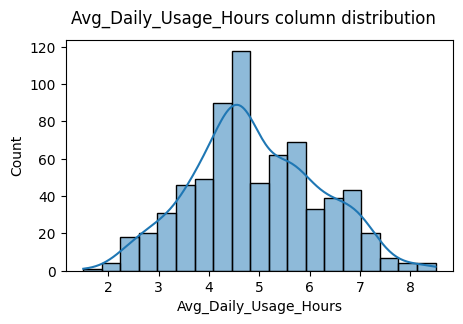

In [3]:
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Avg_Daily_Usage_Hours', 
    kde=True, 
    bins='auto'
)
plt.suptitle("Avg_Daily_Usage_Hours column distribution")

plt.show()

This plot depicts a histogram highlighting the distribution of the Avg_Daily_Usage_Hours feature.
These results shows an approximately symmetric, but slightly skewed distribution.

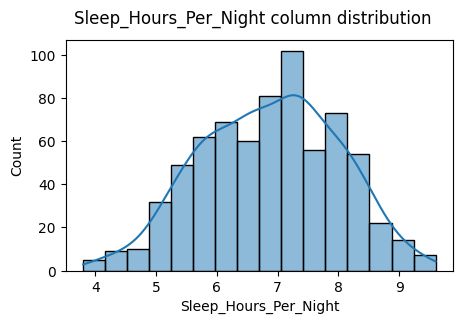

In [4]:
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Sleep_Hours_Per_Night', 
    kde=True, 
    bins='auto'
)
plt.suptitle("Sleep_Hours_Per_Night column distribution")
plt.show()

Similarly, this plot depicts a histogram highlighting the distribution of the Sleep_Hours_Per_Night feature.
The distribution of the values are close enough to normal distribution, although a little bit skewed to the right.

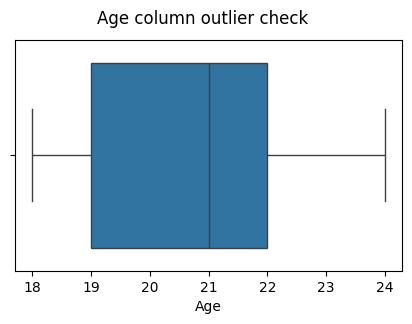

In [5]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x='Age')
plt.suptitle("Age column outlier check")
plt.show()

The boxplot suggests a relatively symmetric distribution with no evident outliers, though the exact distribution shape cannot be inferred solely from this visualization.

#### Demographic analysis

This section examines the distribution of observations across countries in order to identify potential imbalances in the dataset.

To ensure sufficient representation, only countries with **10 or more observations** were considered to be "sufficient" for analysis. Countries with fewer observations were filtered out to reduce noise and improve readability, reliability and to perform more reliable subsequent comparisons. This threshold was chosen as a minimum sample size constraint to **mitigate the effects of small-sample variability**.

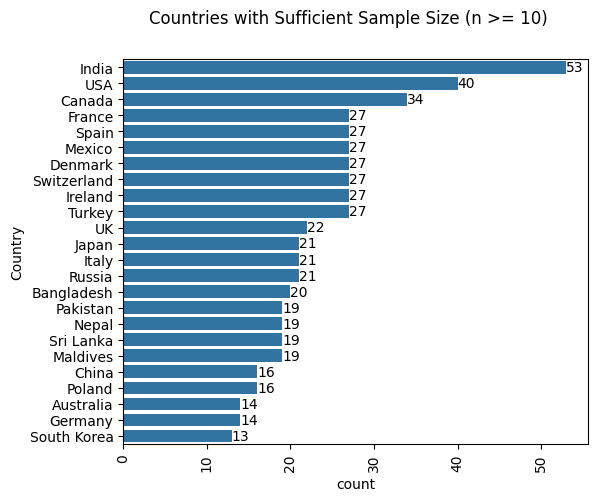

Countries that has ten or more records:  24
Which is only 21.8% of the 110 countries present.


In [7]:
MINIMUM_COUNTRY_OBSERVATION = 10
countries_entries_greater_than_x = df['Country'].value_counts()[df['Country'].value_counts() >= MINIMUM_COUNTRY_OBSERVATION].index #more than 10 records for simplicity
plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=df, 
    y='Country',
    order=countries_entries_greater_than_x.value_counts().index
)
plt.suptitle("Countries with Sufficient Sample Size (n >= 10)")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()
print('Countries that has ten or more records: ', len(df['Country'].value_counts()[df['Country'].value_counts() > MINIMUM_COUNTRY_OBSERVATION].index))
print(f"Which is only {df['Country'].value_counts()[df['Country'].value_counts() > MINIMUM_COUNTRY_OBSERVATION].count() / df['Country'].nunique() * 100:.1f}% of the 110 countries present.")

Out of the 110 countries present in the dataset, only 24 (21.8%) have at least 10 observations. This indicates a high level of sparsity in the country-level distribution, with most countries **being underrepresented**. This imbalance reinforces the need for applying a minimum sample size threshold, as analyses based on small groups would be more susceptible to noise and unstable estimates.

---

## Bivariate Analysis

This section presents plots **between two features** that (potentially) correlate and can present insights not seen before about the data.

#### Countries early insights

The ranking is based on countries with **at least 10 observations**. However, differences in sample size may still affect the stability of the estimated averages.
Having restricted the analysis to countries with sufficient sample size, the next step is to examine which countries exhibit the highest average usage within this subset.


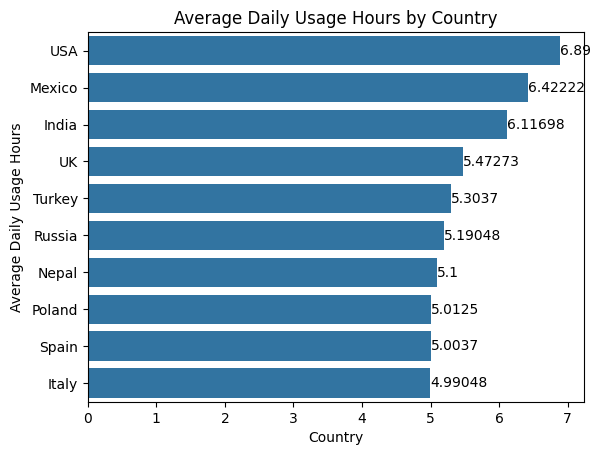

In [8]:
grouped_df = df[df['Country'].isin(countries_entries_greater_than_x)].groupby(by="Country").agg(Avg_usage=('Avg_Daily_Usage_Hours', 'mean')).sort_values(by="Avg_usage", ascending=False).head(10)
ax = sns.barplot(
    data=grouped_df,
    x="Avg_usage",
    y="Country"
)
ax.bar_label(ax.containers[0])

plt.xlabel("Country")

plt.ylabel("Average Daily Usage Hours")
plt.title("Average Daily Usage Hours by Country")

plt.show()

### Correlation table

This correlation table between the numerical features emphasizes many strong potential connections that can be correlated to provide more insights and different perspective.

Which can be read like this:

<div align="center">

| Correlation (r) | Type |
|:-----------------:|------|
| 0.90 to 1.00 | Very strong positive |
| 0.70 to 0.89 | Strong positive |
| 0.40 to 0.69 | Moderate positive |
| 0.10 to 0.39 | Weak positive |
| -0.09 to 0.09 | No correlation |
| -0.10 to -0.39 | Weak negative |
| -0.40 to -0.69 | Moderate negative |
| -0.70 to -0.89 | Strong negative |
| -0.90 to -1.00 | Very strong negative |
</div>

e.g.: As Avg_Daily_Usage_Hours increases, Sleep_Hours_Per_Night strongly decreases (will be shown later on regresstion plots).

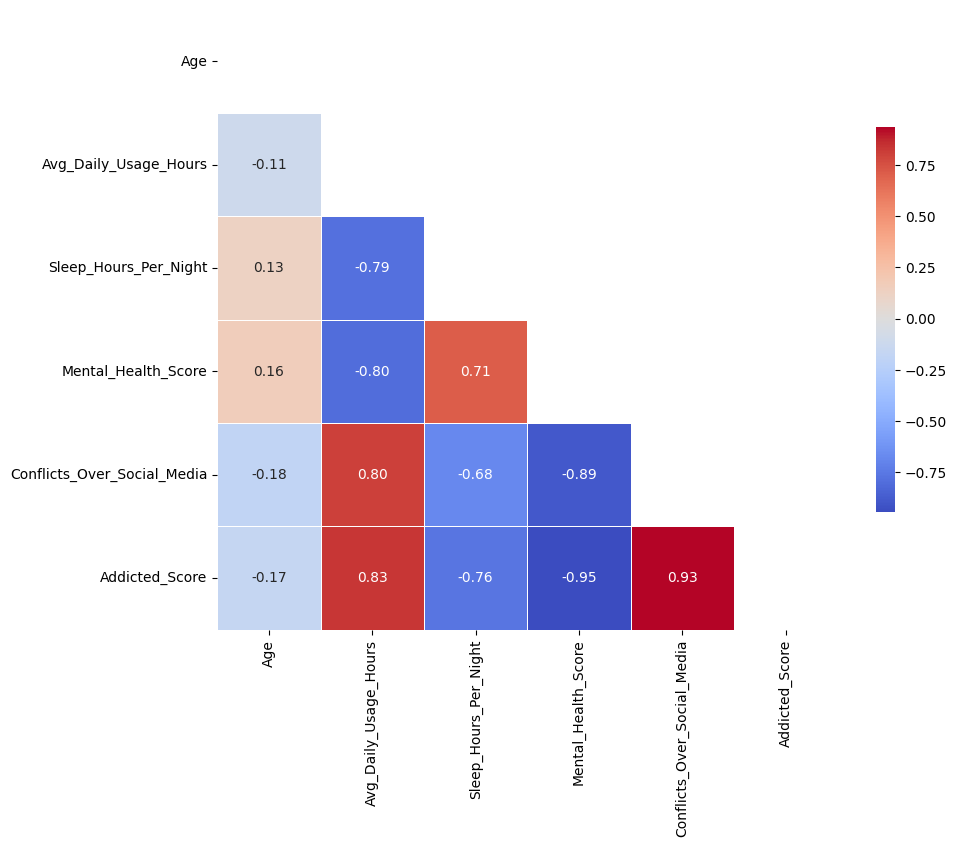

In [9]:
df_numeric = df.select_dtypes(['number'])
df_noIds = df_numeric.drop(columns=['Student_ID'])
corr_matrix = df_noIds.corr()

plt.figure(figsize=(10, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

These correlation coefficients provide some insights about how the features interact with each other. This information will be used heavily throughout this notebook.

### Plotting the regression plots using **Avg_Daily_Usage_Hours** as pinpoint

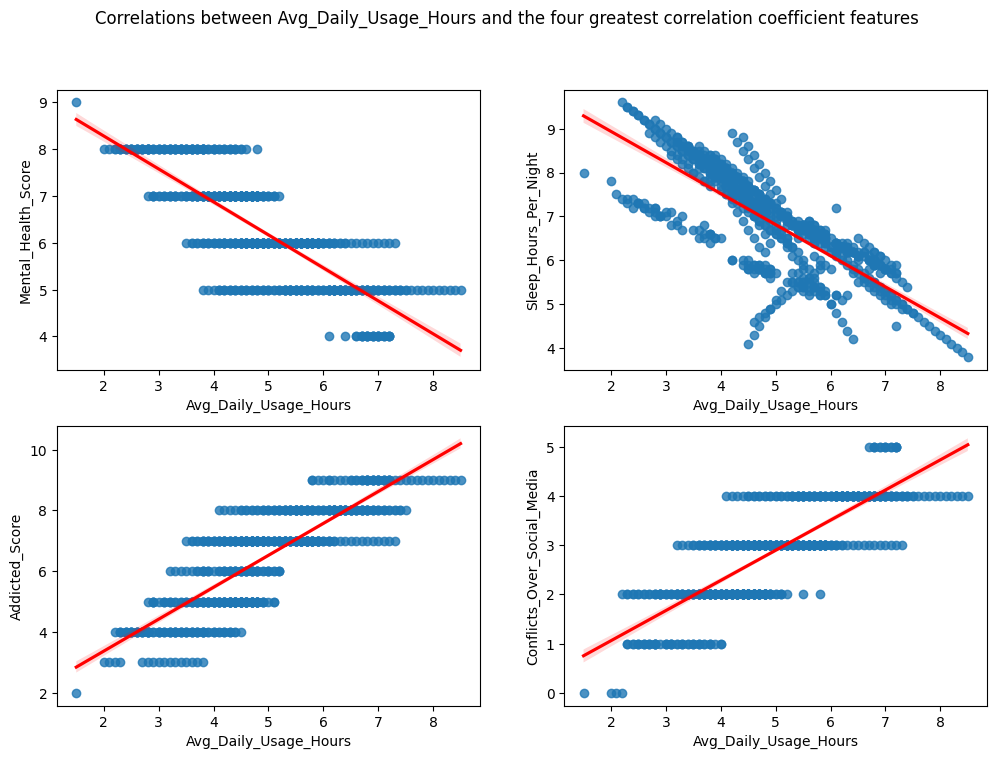

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
ax0 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Mental_Health_Score',
    order=1,
    ax=axes[0][0],
    line_kws=dict(color="r")
)
ax1 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    order=1,
    ax=axes[0][1],
    line_kws=dict(color="r")
)
ax2 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Addicted_Score',
    order=1,
    ax=axes[1][0],
    line_kws=dict(color="r")
)

ax2 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Conflicts_Over_Social_Media',
    order=1,
    ax=axes[1][1],
    line_kws=dict(color="r")
)
plt.suptitle("Correlations between Avg_Daily_Usage_Hours and the four greatest correlation coefficient features")

plt.show()

The four plots have Avg_Daily_Usage_Hours feature in X axis, as this is one of the most influential features in the correlation matrix. It's now possible not only to confirm the correlation's insight, but craft regressions or classification using these variables.

---

### Plotting regression plots using **Addicted_Score** as pinpoint

Similarly, based on the same correlation matrix, it's possible to use Addicted_Score as an influential variable as well, as it has four strong correlation relationships.

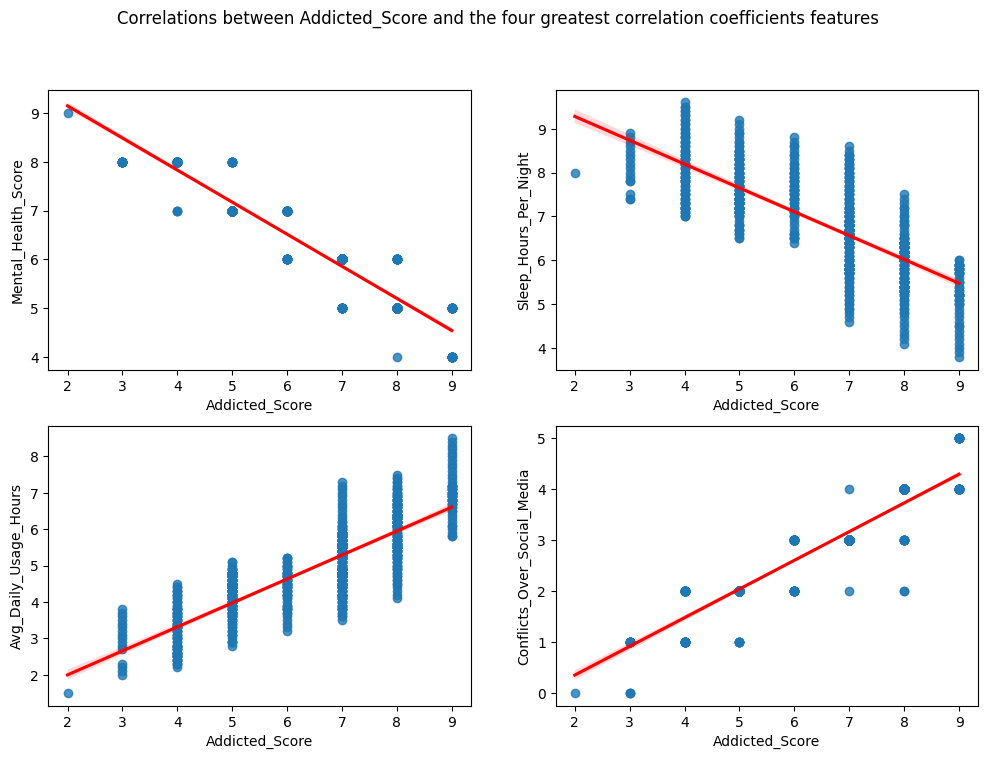

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
ax0 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Mental_Health_Score',
    order=1,
    ax=axes[0][0],
    line_kws=dict(color="r")
)
ax1 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Sleep_Hours_Per_Night',
    order=1,
    ax=axes[0][1],
    line_kws=dict(color="r")
)
ax2 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Avg_Daily_Usage_Hours',
    order=1,
    ax=axes[1][0],
    line_kws=dict(color="r")
)

ax2 = sns.regplot(
    data=df,
    x='Addicted_Score',
    y='Conflicts_Over_Social_Media',
    order=1,
    ax=axes[1][1],
    line_kws=dict(color="r")
)
plt.suptitle("Correlations between Addicted_Score and the four greatest correlation coefficients features")

plt.show()

Addicted_Score shows strong correlation with several other features:
- Mental_Health_Score
- Sleep_Hours_Per_Night
- Addicted_Score
- Conflicts_Over_Social_Media

Which can be seen as a behavioral association, because usage hours tends to be associated with:
- Decreased mental health score
- Less sleep (quantity/quality)
- More time spent on social media
- More conflicts

### Deeper analysis based on Addicted_Score

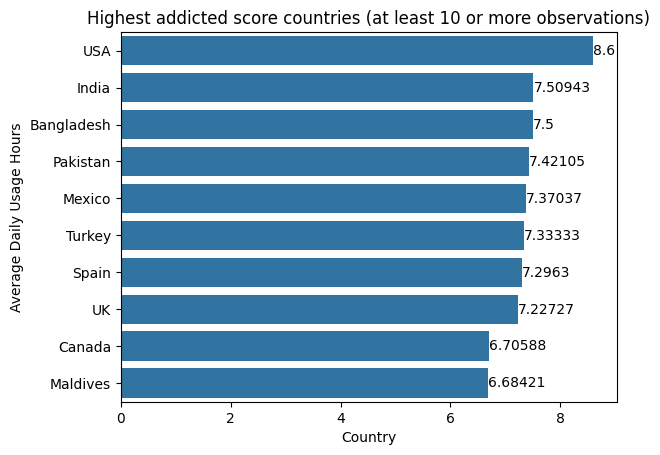

In [12]:
AVG_COUNTRY_ADDICTED_SCORE_GT_10_OBSERVATIONS = df[df['Country'].isin(countries_entries_greater_than_x)].groupby("Country").agg(Avg_Country_Addicted_Score=('Addicted_Score', 'mean'), Avg_Country_Usage_Hours=('Avg_Daily_Usage_Hours', 'mean')).sort_values(by="Avg_Country_Addicted_Score", ascending=False).head(10)
# print(AVG_COUNTRY_ADDICTED_SCORE_GT_10_OBSERVATIONS)
ax = sns.barplot(
    data=AVG_COUNTRY_ADDICTED_SCORE_GT_10_OBSERVATIONS,
    x="Avg_Country_Addicted_Score",
    y="Country",
)
ax.bar_label(ax.containers[0])
plt.xlabel("Country")
plt.ylabel("Average Daily Usage Hours")
plt.title("Highest addicted score countries (at least 10 or more observations)")

plt.show()

### Top 3 addicted score subgroup in-depth analysis

This subdivision can provide insights that only occur in countries with the highest addiction score [...]

Text(0.5, 0.98, 'TOP 3 most addicted countries insights')

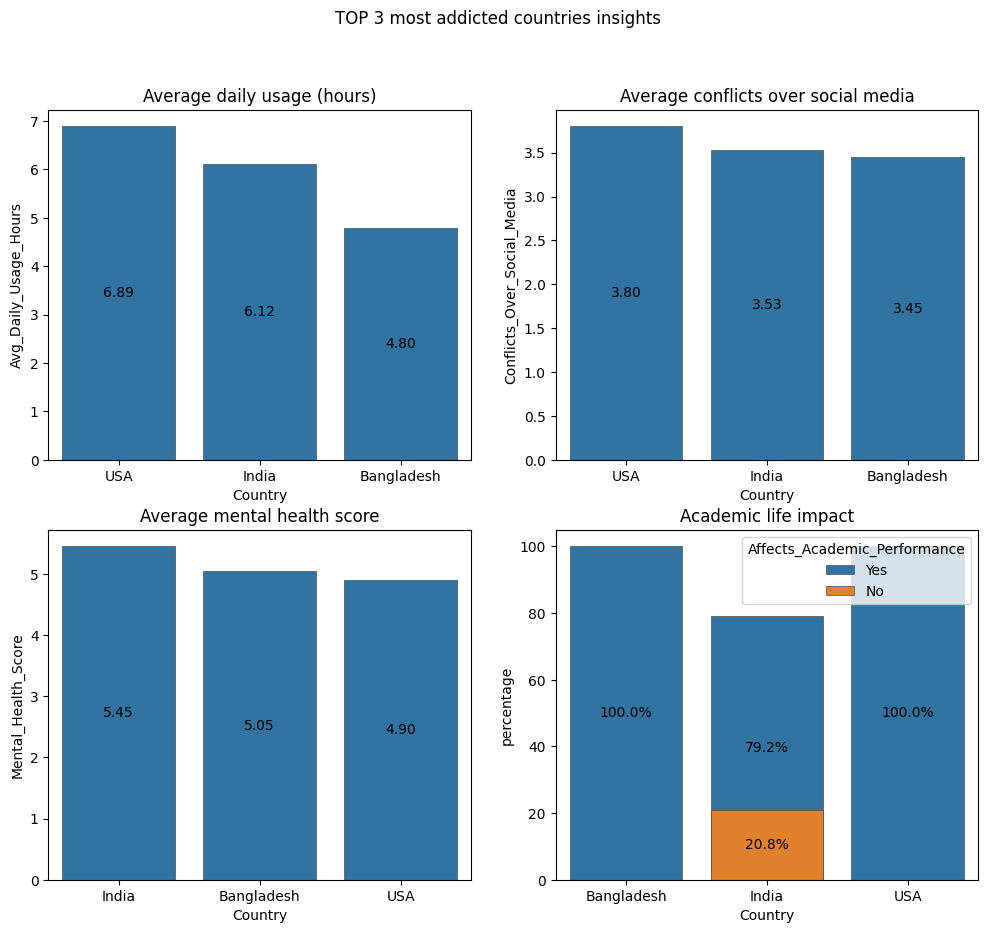

In [13]:
top_3_addicted_score_countries = AVG_COUNTRY_ADDICTED_SCORE_GT_10_OBSERVATIONS.head(3).index
addicted_subgroup_rows = df[df['Country'].isin(top_3_addicted_score_countries)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax0 = sns.barplot(
    addicted_subgroup_rows.groupby("Country").agg({'Avg_Daily_Usage_Hours': 'mean'}).sort_values('Avg_Daily_Usage_Hours', ascending=False),
    y='Avg_Daily_Usage_Hours',
    x="Country",
    edgecolor=".3",
    linewidth=.5,
    ax=axes[0][0]
)
for container in ax0.containers:
    labels = [
        f'{(v.get_height()):.2f}'
        for v in container
    ]
    ax0.bar_label(container, labels=labels, label_type='center')
ax0.set_title("Average daily usage (hours)")

ax1 = sns.barplot(
    addicted_subgroup_rows.groupby("Country").agg({'Conflicts_Over_Social_Media': 'mean'}).sort_values('Conflicts_Over_Social_Media', ascending=False),
    y='Conflicts_Over_Social_Media',
    x="Country",
    edgecolor=".3",
    linewidth=.5,
    ax=axes[0][1]
)
for container in ax1.containers:
    labels = [
        f'{(v.get_height()):.2f}'
        for v in container
    ]
    ax1.bar_label(container, labels=labels, label_type='center')
ax1.set_title("Average conflicts over social media")

ax2 = sns.barplot(
    addicted_subgroup_rows.groupby("Country").agg({'Mental_Health_Score': 'mean'}).sort_values('Mental_Health_Score', ascending=False),
    y='Mental_Health_Score',
    x="Country",
    edgecolor=".3",
    linewidth=.5,
    ax=axes[1][0]
)
for container in ax2.containers:
    labels = [
        f'{(v.get_height()):.2f}'
        for v in container
    ]
    ax2.bar_label(container, labels=labels, label_type='center')
ax2.set_title("Average mental health score")

# print(addicted_subgroup_rows.groupby("Country")['Affects_Academic_Performance'].value_counts(normalize=True).mul(100).round(1).reset_index(name='percentage'))
ax3 = sns.barplot(
    addicted_subgroup_rows.groupby("Country")['Affects_Academic_Performance'].value_counts(normalize=True).mul(100).round(1).reset_index(name='percentage'),
    x="Country",
    y="percentage",
    hue='Affects_Academic_Performance',
    dodge=False,
    edgecolor=".3",
    linewidth=.5,
    ax=axes[1][1]
)
for container in ax3.containers:
    labels = [
        f'{(v.get_height()):.1f}%'
        for v in container
    ]
    ax3.bar_label(container, labels=labels, label_type='center')
ax3.set_title("Academic life impact")

plt.suptitle("TOP 3 most addicted countries insights")

---

## Multivariate Analysis

This section presents plots **between three or more features** that (potentially) correlate and can present insights not seen before about the data.

#### Platform usage and Average daily usage

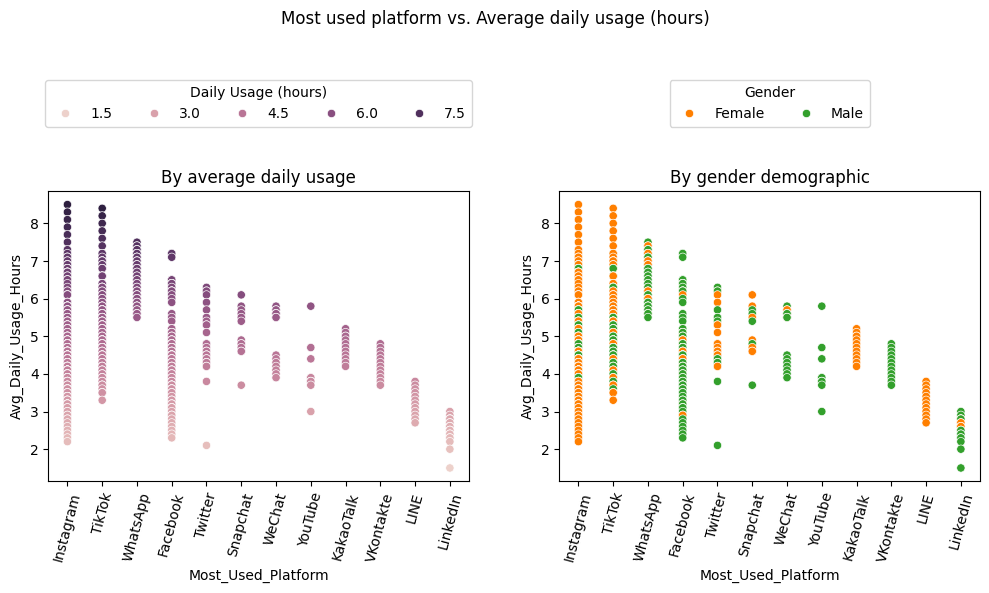

In [17]:
df_sorted = df.sort_values(by="Avg_Daily_Usage_Hours", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10,6))
ax1 = sns.scatterplot(
    data=df_sorted,
    x='Most_Used_Platform',
    y='Avg_Daily_Usage_Hours',
    hue='Avg_Daily_Usage_Hours',
    ax=axes[0]
)
ax1.set_title("By average daily usage")
axes[0].tick_params(axis='x', rotation=75)
sns.move_legend(
    ax1, "lower center",
    bbox_to_anchor=(.5, 1.2), ncol=5,
    title='Daily Usage (hours)', frameon=True
)

ax2 = sns.scatterplot(
    data=df_sorted,
    x='Most_Used_Platform',
    y='Avg_Daily_Usage_Hours',
    hue='Gender',
    palette="Paired_r",
    ax=axes[1]
)
ax2.set_title("By gender demographic")
axes[1].tick_params(axis='x', rotation=75)
sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(.5, 1.2), ncol=5,
    title='Gender', frameon=True
)
plt.suptitle("Most used platform vs. Average daily usage (hours)")
plt.tight_layout()
plt.show()

Correlation between **most used platforms vs. the daily usage** shows that the Instagram and Tiktok are the most used platforms **in the sample**. It also shows the variety of the time spent by students in these different social media applications.
These plots shows the same data under different perspectives, the first shows a distribution of the time spent (in hours), while the latter highlight the gender that uses each platform the most.

#### Sleep hours vs. Daily usage (hours) deeper analysis

This section provides a deeper analysis of the regression plot above (second plot, specifically). The goal is to visualize the same plot under different perspectives. Then subdivide the dataframe to obtain even more information. 

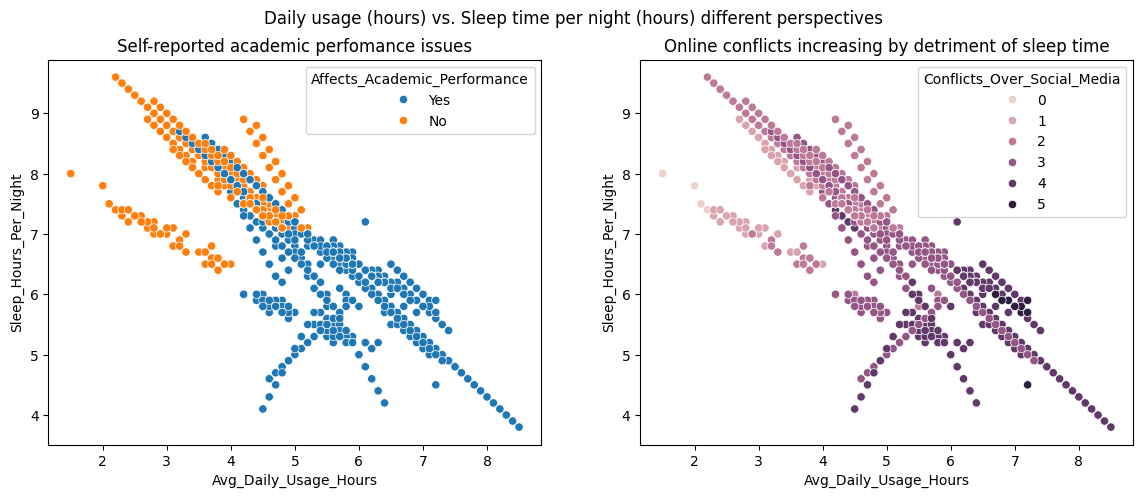

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
ax1 = sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Affects_Academic_Performance',
    ax=axes[0]
)
ax1.set_title("Self-reported academic perfomance issues")

ax2 = sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Conflicts_Over_Social_Media',
    ax=axes[1]
)
ax2.set_title("Online conflicts increasing by detriment of sleep time")
plt.suptitle("Daily usage (hours) vs. Sleep time per night (hours) different perspectives")
plt.show()

#### Subdividing the dataframe

By subdividing the data frame in two portions, it's possible to dive deeper and highlight insights about the data demographic. In these next two plots, the data is subdivised into: Those who claimed academic performance issues due to the social media addiction, and those who claimed no academic performance issues.

Question can be raised just like the following:
- In which academic level students reported affected academic performance the most?
- In which academic level students reported not being affected by social media addiction?

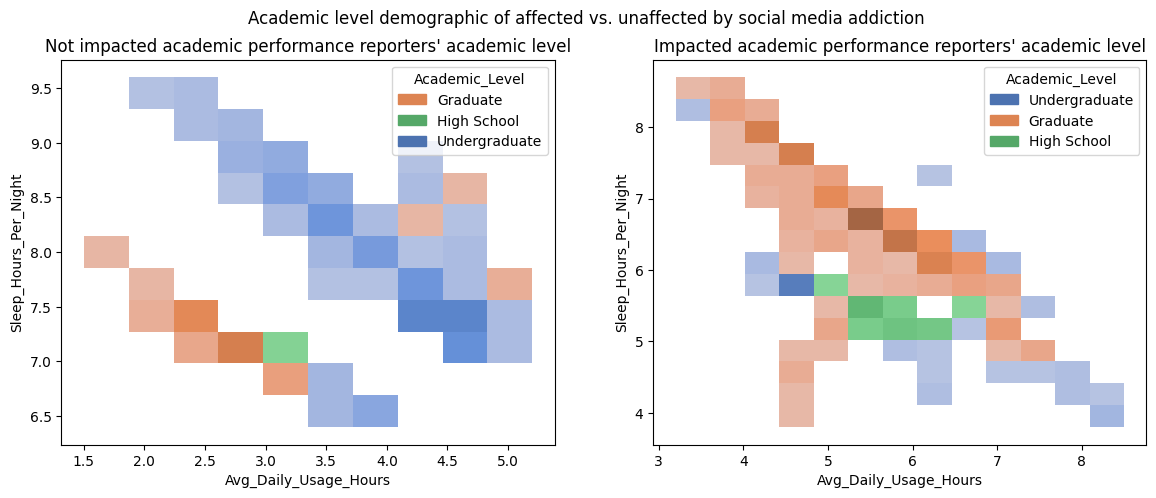

In [19]:
# Dataframe subdivisions
sub_df_self_reported_academic_performance_problems = df[df['Affects_Academic_Performance'] == 'Yes']
sub_df_self_reported_academic_performance_no_problems = df[df['Affects_Academic_Performance'] == 'No']

custom_palette = {
    "High School": "#55a868",
    "Undergraduate": "#4c72b0",
    "Graduate": "#dd8452"
}

fig, axes = plt.subplots(1, 2, figsize=(14,5))

ax0 = sns.histplot(
    data=sub_df_self_reported_academic_performance_no_problems,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Academic_Level',
    ax=axes[0],
    palette=custom_palette
)
ax0.set_title("Not impacted academic performance reporters' academic level")


ax1 = sns.histplot(
    data=sub_df_self_reported_academic_performance_problems,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Academic_Level',
    ax=axes[1],
    palette=custom_palette
)
ax1.set_title("Impacted academic performance reporters' academic level")

plt.suptitle("Academic level demographic of affected vs. unaffected by social media addiction")
plt.show()

The majority of responses shows that, Graduate academic level students are the majority who self-reported negative impact in their academic life. While most Undergraduate self-reported no impact.
It's also possible to check the difference in daily usage for both groups.

## Key insights & Final considerations